In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../Datasets/mpg.csv')

In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
df = df.drop(columns=['name','origin'])
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
print (df.shape, "|", df.isna().sum().sum(), "missing")
print(df.head())

(398, 7) | 0 missing
    mpg  cylinders  displacement  horsepower  weight  acceleration  model_year
0  18.0          8         307.0       130.0    3504          12.0          70
1  15.0          8         350.0       165.0    3693          11.5          70
2  18.0          8         318.0       150.0    3436          11.0          70
3  16.0          8         304.0       150.0    3433          12.0          70
4  17.0          8         302.0       140.0    3449          10.5          70


In [7]:
x = df.drop(columns='mpg')
y = df['mpg']
print (x.shape , y.shape)

(398, 6) (398,)


In [8]:
from sklearn.model_selection import train_test_split as tts

In [9]:

x_train, x_test, y_train, y_test = tts (
    x, y, test_size=0.2, random_state=42
)

print (x_train.shape, x_test.shape)

(318, 6) (80, 6)


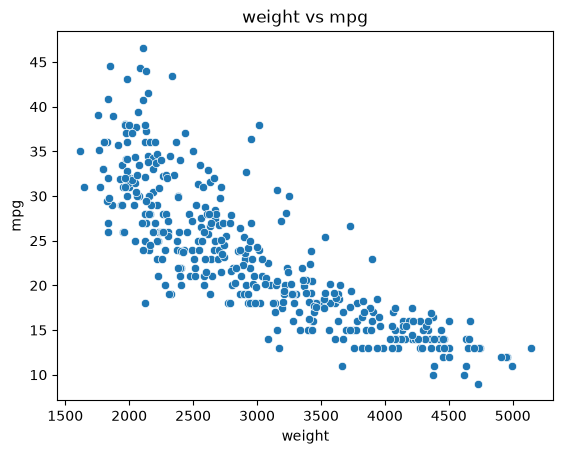

In [10]:
sns.scatterplot(data = df , x = 'weight' , y= 'mpg')
plt.title('weight vs mpg')
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression as lr

In [24]:
model = lr()
model.fit (x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.07, 0. , 0. ,-0.01, 0.08, 0.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['cylinders','displacement','horsepower','weight','acceleration', 'model_year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-18.71
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [25]:
print ("coef:     ", model.coef_)
print("intercept:", model.intercept_)

coef:      [ 0.06904916  0.00160356  0.00289823 -0.0070437   0.08061413  0.80136485]
intercept: -18.70827174013082


In [35]:
print (model.score(x_test,y_test)) #r2 score

0.824424533094336


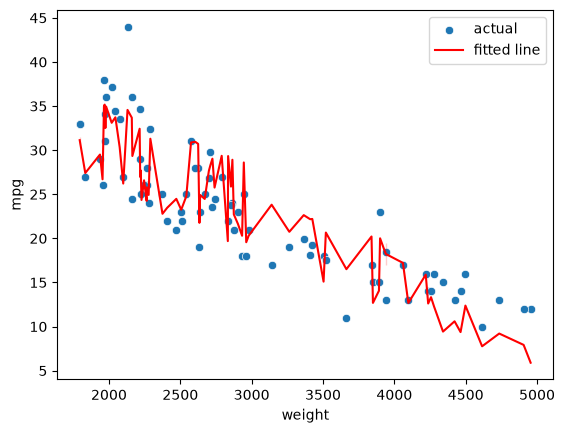

In [34]:


sns.scatterplot(x=x_test['weight'], y=y_test, label='actual')

sns.lineplot(
    x=x_test['weight'],
    y=model.predict(x_test),
    color='red',
    label='fitted line'
)

plt.show()


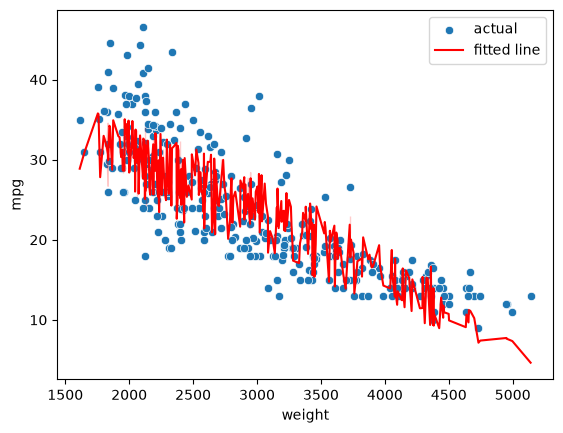

In [36]:
sns.scatterplot(x=x_train['weight'],y=y_train,label='actual')
sns.lineplot(x=x_train['weight'],y=model.predict(x_train),
             color='red',label='fitted line')
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler


In [37]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print (x_train_scaled.shape, x_test_scaled.shape)

(318, 6) (80, 6)


In [39]:
print (model.score(x_test,y_test))
print (model_scaled.score(x_test_scaled,y_test))

0.824424533094336
0.8244245330943359


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [43]:
knn = KNeighborsRegressor()
knn.fit(x_train,y_train)
acc_knn_raw = knn.score(x_test,y_test)
print(round(acc_knn_raw, 3))

0.766


In [46]:
knn_scaled = KNeighborsRegressor()
knn_scaled.fit(x_train_scaled,y_train)
acc_knn_raw1 = knn_scaled.score(x_test_scaled,y_test)
print(round(acc_knn_raw1, 3))

0.879


In [47]:
pd.DataFrame({
    'model':['Linear Regression',
             'KNN Regressor (no scaling)',
             'KNN Regressor (scaled)'],
    'R2' :[round(model.score(x_test,y_test),4),
           round(acc_knn_raw, 4),
           round(acc_knn_raw1, 4)]

})

,model,R2
0,Linear Regression,0.8244
1,KNN Regressor (no scaling),0.7660
2,KNN Regressor (scaled),0.8785
